# Employee Salary Prediction Pipeline
**AI/ML Build Week - Day 6 Assignment**

This notebook builds a complete end-to-end ML pipeline to predict employee salaries using:
- `Pipeline` and `ColumnTransformer` from scikit-learn
- Missing value handling, categorical encoding, and feature scaling
- Multiple regression models with evaluation metrics
- Model saving with `joblib`

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load and Explore the Dataset

In [2]:
df = pd.read_csv('data.csv')
print(f'Dataset Shape: {df.shape}')
df.head(10)

Dataset Shape: (99, 7)


,Age,Gender,Education,Job_Title,Years_Experience,Department,Salary
0,28,Male,Bachelor's,Software Engineer,3,Engineering,72000
1,35,Female,Master's,Data Scientist,7,Data Science,105000
2,42,Male,PhD,Senior Manager,15,Management,145000
3,30,Female,Bachelor's,HR Specialist,5,HR,58000
4,25,Male,Bachelor's,Junior Developer,1,Engineering,52000
5,38,Female,Master's,Product Manager,10,Product,115000
6,45,Male,PhD,Director,18,Management,175000
7,32,Female,Bachelor's,Data Analyst,6,Data Science,78000
8,29,Male,Master's,ML Engineer,4,Engineering,95000
9,52,Female,Bachelor's,Senior HR Manager,22,HR,92000


In [3]:
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               99 non-null     int64
 1   Gender            99 non-null     str  
 2   Education         99 non-null     str  
 3   Job_Title         99 non-null     str  
 4   Years_Experience  99 non-null     int64
 5   Department        99 non-null     str  
 6   Salary            99 non-null     int64
dtypes: int64(3), str(4)
memory usage: 5.5 KB


In [4]:
print('Statistical Summary:')
df.describe()

Statistical Summary:


,Age,Years_Experience,Salary
count,99.000000,99.000000,99.000000
mean,35.797980,9.464646,109888.888889
std,8.194049,6.850165,42799.458534
min,24.000000,0.000000,38000.000000
25%,29.000000,4.000000,81000.000000
50%,35.000000,8.000000,108000.000000
75%,42.000000,15.000000,135000.000000
max,55.000000,25.000000,225000.000000


In [5]:
print('Missing Values:')
print(df.isnull().sum())

Missing Values:
Age                 0
Gender              0
Education           0
Job_Title           0
Years_Experience    0
Department          0
Salary              0
dtype: int64


In [6]:
# Introduce some missing values to demonstrate handling
np.random.seed(42)
missing_idx_num = np.random.choice(df.index, size=8, replace=False)
missing_idx_cat = np.random.choice(df.index, size=6, replace=False)

df.loc[missing_idx_num, 'Years_Experience'] = np.nan
df.loc[missing_idx_cat, 'Department'] = np.nan

print('Missing Values after injection:')
print(df.isnull().sum())

Missing Values after injection:
Age                 0
Gender              0
Education           0
Job_Title           0
Years_Experience    8
Department          6
Salary              0
dtype: int64


## 3. Exploratory Data Analysis (EDA)

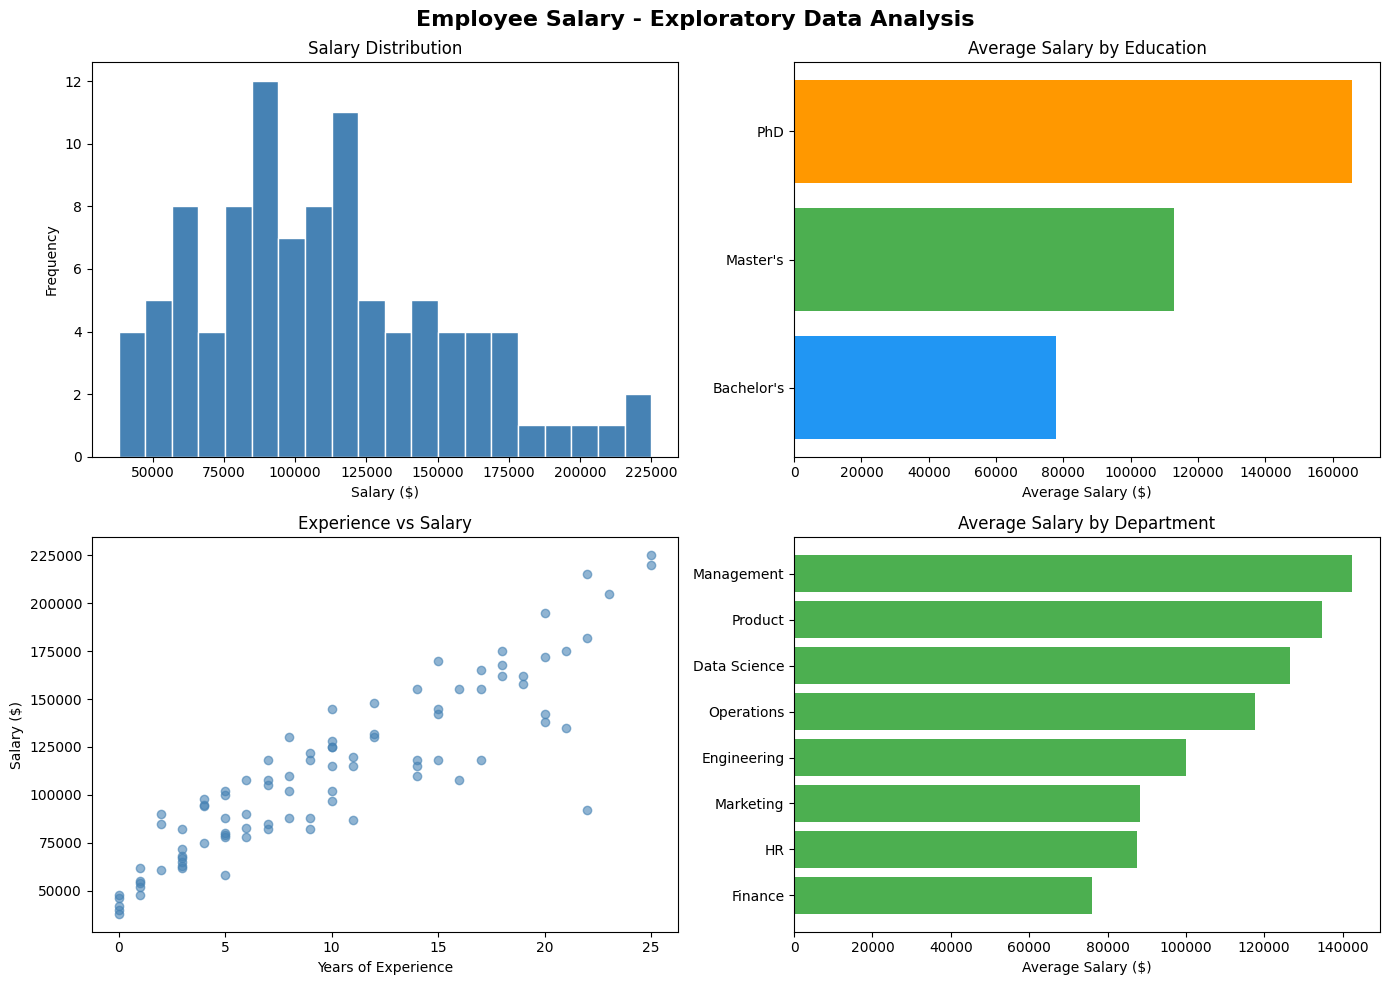

EDA plots saved


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Employee Salary - Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Salary distribution
axes[0, 0].hist(df['Salary'].dropna(), bins=20, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Salary Distribution')
axes[0, 0].set_xlabel('Salary ($)')
axes[0, 0].set_ylabel('Frequency')

# Salary by Education
edu_salary = df.groupby('Education')['Salary'].mean().sort_values()
axes[0, 1].barh(edu_salary.index, edu_salary.values, color=['#2196F3', '#4CAF50', '#FF9800'])
axes[0, 1].set_title('Average Salary by Education')
axes[0, 1].set_xlabel('Average Salary ($)')

# Years of Experience vs Salary
axes[1, 0].scatter(df['Years_Experience'], df['Salary'], alpha=0.6, color='steelblue')
axes[1, 0].set_title('Experience vs Salary')
axes[1, 0].set_xlabel('Years of Experience')
axes[1, 0].set_ylabel('Salary ($)')

# Salary by Department
dept_salary = df.groupby('Department')['Salary'].mean().sort_values()
axes[1, 1].barh(dept_salary.index, dept_salary.values, color='#4CAF50')
axes[1, 1].set_title('Average Salary by Department')
axes[1, 1].set_xlabel('Average Salary ($)')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA plots saved')

## 4. Feature Engineering & Data Preparation

In [8]:
# Define features and target
X = df.drop(columns=['Salary'])
y = df['Salary']

# Define numerical and categorical columns
numerical_cols = ['Age', 'Years_Experience']
categorical_cols = ['Gender', 'Education', 'Job_Title', 'Department']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nNumerical features: {numerical_cols}')
print(f'Categorical features: {categorical_cols}')

Features shape: (99, 6)
Target shape: (99,)

Numerical features: ['Age', 'Years_Experience']
Categorical features: ['Gender', 'Education', 'Job_Title', 'Department']


In [9]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set size: {X_train.shape[0]} samples')
print(f'Test set size: {X_test.shape[0]} samples')

Training set size: 79 samples
Test set size: 20 samples


## 5. Build the Preprocessing Pipeline

In [10]:
# Numerical pipeline: impute missing → scale
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),   # Handle missing values
    ('scaler', StandardScaler())                      # Scale features
])

# Categorical pipeline: impute missing → one-hot encode
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Handle missing values
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # Encode
])

# Combine using ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

print('Preprocessing pipeline built!')
print('\nPipeline structure:')
print('  Numerical: SimpleImputer(median) -> StandardScaler')
print('  Categorical: SimpleImputer(most_frequent) -> OneHotEncoder')

Preprocessing pipeline built!

Pipeline structure:
  Numerical: SimpleImputer(median) -> StandardScaler
  Categorical: SimpleImputer(most_frequent) -> OneHotEncoder


## 6. Train Models & Evaluate

In [11]:
def evaluate_model(name, pipeline, X_train, X_test, y_train, y_test):
    """Train and evaluate a model pipeline, return metrics."""
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f'\n{name}')
    print(f'   MAE  : ${mae:,.2f}')
    print(f'   RMSE : ${rmse:,.2f}')
    print(f'   R²   : {r2:.4f}')
    
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'pipeline': pipeline, 'predictions': y_pred}

In [12]:
results = []

# Model 1: Linear Regression 
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
results.append(evaluate_model('Linear Regression', lr_pipeline, X_train, X_test, y_train, y_test))

# Model 2: Decision Tree Regressor 
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(max_depth=8, random_state=42))
])
results.append(evaluate_model('Decision Tree Regressor', dt_pipeline, X_train, X_test, y_train, y_test))

# Model 3: Random Forest Regressor 
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])
results.append(evaluate_model('Random Forest Regressor', rf_pipeline, X_train, X_test, y_train, y_test))


Linear Regression
   MAE  : $11,911.04
   RMSE : $18,759.88
   R²   : 0.7635

Decision Tree Regressor
   MAE  : $12,425.00
   RMSE : $15,028.72
   R²   : 0.8482

Random Forest Regressor
   MAE  : $8,943.08
   RMSE : $12,243.44
   R²   : 0.8993


In [13]:
# Summary table
results_df = pd.DataFrame([{'Model': r['model'], 'MAE': r['MAE'], 'RMSE': r['RMSE'], 'R² Score': r['R2']} for r in results])
results_df = results_df.sort_values('R² Score', ascending=False).reset_index(drop=True)

print('\nModel Comparison Summary:')
print(results_df.to_string(index=False))


Model Comparison Summary:
                  Model          MAE         RMSE  R² Score
Random Forest Regressor  8943.075000 12243.440922  0.899253
Decision Tree Regressor 12425.000000 15028.722501  0.848202
      Linear Regression 11911.037635 18759.881999  0.763471


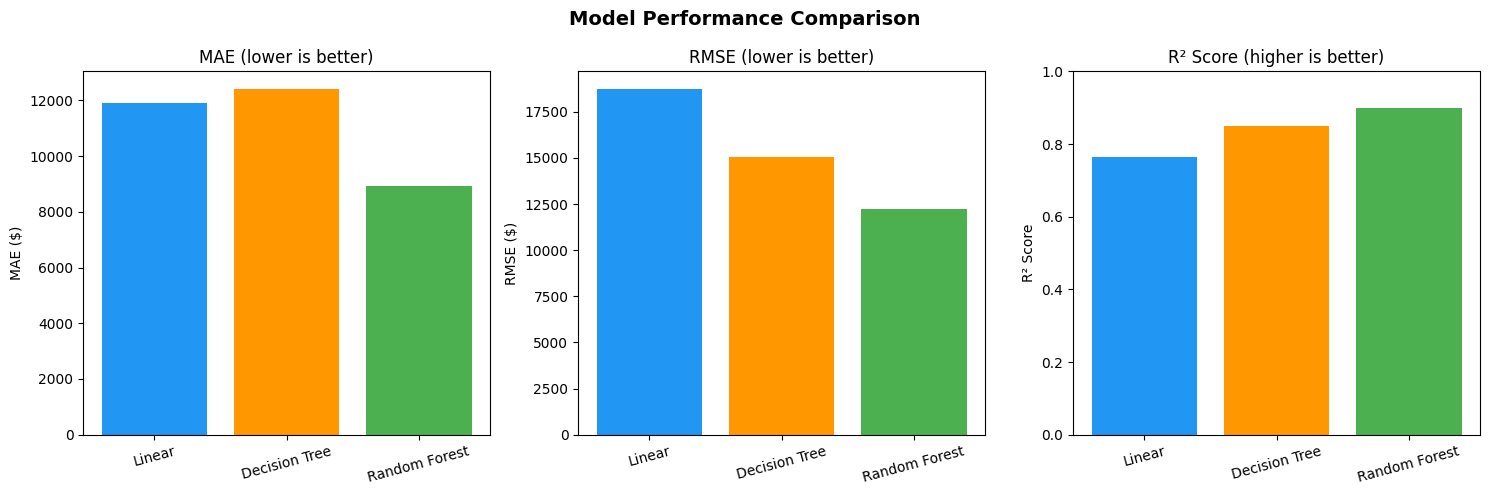

Model comparison chart saved!


In [14]:
# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')

colors = ['#2196F3', '#FF9800', '#4CAF50']
model_names = [r['model'].replace(' Regressor', '').replace(' Regression', '') for r in results]

axes[0].bar(model_names, [r['MAE'] for r in results], color=colors)
axes[0].set_title('MAE (lower is better)')
axes[0].set_ylabel('MAE ($)')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(model_names, [r['RMSE'] for r in results], color=colors)
axes[1].set_title('RMSE (lower is better)')
axes[1].set_ylabel('RMSE ($)')
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(model_names, [r['R2'] for r in results], color=colors)
axes[2].set_title('R² Score (higher is better)')
axes[2].set_ylabel('R² Score')
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Model comparison chart saved!')

Best Model: Random Forest Regressor (R² = 0.8993)


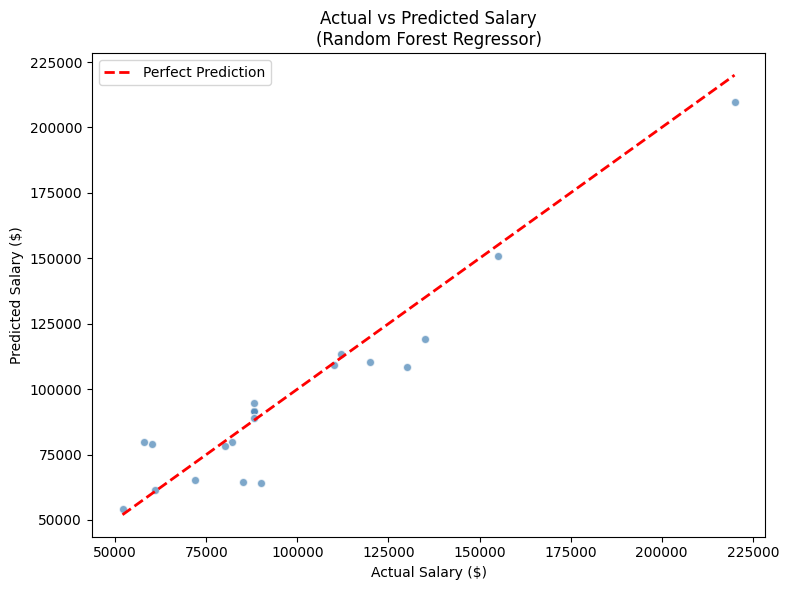

Actual vs Predicted chart saved!


In [15]:
# Actual vs Predicted plot for the best model
best_result = max(results, key=lambda x: x['R2'])
print(f'Best Model: {best_result["model"]} (R² = {best_result["R2"]:.4f})')

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_result['predictions'], alpha=0.7, color='steelblue', edgecolors='white')
min_val = min(y_test.min(), best_result['predictions'].min())
max_val = max(y_test.max(), best_result['predictions'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Salary ($)')
plt.ylabel('Predicted Salary ($)')
plt.title(f'Actual vs Predicted Salary\n({best_result["model"]})')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Actual vs Predicted chart saved!')

## 7. Save the Best Pipeline

In [16]:
# Save the best-performing pipeline
best_pipeline = best_result['pipeline']
joblib.dump(best_pipeline, 'salary_pipeline.pkl')

print(f'Best pipeline saved as "salary_pipeline.pkl"')
print(f'   Model: {best_result["model"]}')
print(f'   R² Score: {best_result["R2"]:.4f}')
print(f'   MAE: ${best_result["MAE"]:,.2f}')
print(f'   RMSE: ${best_result["RMSE"]:,.2f}')

Best pipeline saved as "salary_pipeline.pkl"
   Model: Random Forest Regressor
   R² Score: 0.8993
   MAE: $8,943.08
   RMSE: $12,243.44


## 8. Quick Verification

In [17]:
# Verify the saved model loads and predicts correctly
loaded_pipeline = joblib.load('salary_pipeline.pkl')

sample = pd.DataFrame([{
    'Age': 32,
    'Gender': 'Female',
    'Education': "Master's",
    'Job_Title': 'Data Scientist',
    'Years_Experience': 6,
    'Department': 'Data Science'
}])

predicted_salary = loaded_pipeline.predict(sample)[0]
print(f'Pipeline loaded and working!')
print(f'\nSample Employee: 32-year-old Female Data Scientist with 6 years experience')
print(f'Predicted Salary: ${predicted_salary:,.2f}')

Pipeline loaded and working!

Sample Employee: 32-year-old Female Data Scientist with 6 years experience
Predicted Salary: $104,340.00
